# Phase 1 — Geospatial Data Ingestion & Spectral Analysis

**Project:** GeoVision QA — Satellite Intelligence Pipeline  
**Goal:** Pull Sentinel-2 multispectral imagery, process it, compute spectral indices,
and export clean GeoTIFFs ready for Phase 2 (object detection & segmentation).

## What you'll learn
- How Sentinel-2 bands map to real-world phenomena
- How cloud masking works
- What NDVI, NDWI, NDBI actually measure
- How to read and write GeoTIFFs with `rasterio`
- How to build a median composite from a scene collection

## Prerequisites
- GCP project with Earth Engine API enabled
- Service account OR personal Google account

---

## 0 · Setup

In [1]:
# Install dependencies (run once)
# On a GCP VM these are typically already available except earthengine-api
!pip install earthengine-api rasterio matplotlib numpy --quiet

In [2]:
import sys
sys.path.append('../src')   # so we can import our modules

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import ee
import rasterio

from geo_ingest import init_earth_engine, get_sentinel2_composite, export_to_drive, export_to_gcs
from band_math  import compute_all_indices, true_colour, false_colour_vegetation
from raster_io  import read_geotiff, write_geotiff, get_tile_info
from visualize  import plot_rgb, plot_index, plot_index_dashboard, plot_band_histograms

DATA_DIR = Path('../data')
RAW_DIR  = DATA_DIR / 'raw'
PROC_DIR = DATA_DIR / 'processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1 · Authenticate with Earth Engine

On a GCP VM with a service account linked to Earth Engine, this is automatic.
On a personal machine it opens a browser OAuth flow the first time.

In [4]:
# ⚠️  Replace with your actual GCP project ID
GCP_PROJECT = 'weighty-media-416305'

init_earth_engine(GCP_PROJECT)

Earth Engine initialised. Project: weighty-media-416305


## 2 · Choose your Area of Interest (AOI)

We'll use **Bengaluru** as the default — a good test scene because it has
dense urban cores, surrounding vegetation, and several lakes, so all three
main indices (NDVI, NDWI, NDBI) will show meaningful signal.

Change `lon`, `lat`, and `buffer_km` to any location you're curious about.

In [5]:
# --- AOI config ---
REGION_NAME   = 'bengaluru'
LON, LAT      = 77.626579, 12.934533   # city centre
BUFFER_KM     = 15                 # ~30×30 km tile
START_DATE    = '2024-01-01'
END_DATE      = '2024-05-31'
MAX_CLOUD_PCT = 15

composite, region = get_sentinel2_composite(
    region_name   = REGION_NAME,
    lon           = LON,
    lat           = LAT,
    buffer_km     = BUFFER_KM,
    start_date    = START_DATE,
    end_date      = END_DATE,
    max_cloud_pct = MAX_CLOUD_PCT,
)

[bengaluru] Found 34 scenes after cloud filter (2024-01-01 → 2024-05-31, <15% cloud)


## 3 · Export the composite to GCS

Earth Engine can't write to local disk directly — it queues an async export job.
We export to your GCS bucket, then download.

> **Tip:** The export typically takes 2–10 minutes for a 30×30 km tile at 10m resolution.
> Monitor progress at https://code.earthengine.google.com/tasks

In [8]:
# ⚠️  Replace with your GCS bucket name
GCS_BUCKET = 'geovision-data'
FILENAME   = f'{REGION_NAME}_s2_composite_2024'

task = export_to_gcs(
    image     = composite,
    region    = region,
    filename  = FILENAME,
    bucket    = GCS_BUCKET,
)

# Poll the task (run this cell repeatedly until state = COMPLETED)
print(task.status())

Export task submitted: gs://geovision-data/geovision/phase1/bengaluru_s2_composite_2024.tif
Task ID: CAGHV2TNDL2MAWN4YYUDB5A3
{'state': 'READY', 'description': 'bengaluru_s2_composite_2024', 'priority': 100, 'creation_timestamp_ms': 1779554331553, 'update_timestamp_ms': 1779554331553, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'CAGHV2TNDL2MAWN4YYUDB5A3', 'name': 'projects/weighty-media-416305/operations/CAGHV2TNDL2MAWN4YYUDB5A3'}


In [13]:
# Download the exported GeoTIFF from GCS to the local VM
import subprocess

GCS_PATH  = f'gs://{GCS_BUCKET}/geovision/phase1/{FILENAME}.tif'
LOCAL_TIF = RAW_DIR / f'{FILENAME}.tif'
RAW_DIR.mkdir(parents=True, exist_ok=True)

result = subprocess.run(['gsutil', 'cp', GCS_PATH, str(LOCAL_TIF)], capture_output=True, text=True)
print(result.stdout or 'Download complete.')
if result.returncode != 0:
    print('Error:', result.stderr)

Download complete.


In [12]:
print(task.status())

{'state': 'COMPLETED', 'description': 'bengaluru_s2_composite_2024', 'priority': 100, 'creation_timestamp_ms': 1779554331553, 'update_timestamp_ms': 1779555233049, 'start_timestamp_ms': 1779554336429, 'task_type': 'EXPORT_IMAGE', 'destination_uris': ['https://console.developers.google.com/storage/browser/geovision-data/geovision/phase1/'], 'attempt': 1, 'batch_eecu_usage_seconds': 917.19140625, 'id': 'CAGHV2TNDL2MAWN4YYUDB5A3', 'name': 'projects/weighty-media-416305/operations/CAGHV2TNDL2MAWN4YYUDB5A3'}


## 4 · Inspect the GeoTIFF

Before doing any analysis, always sanity-check the file.
Check: dimensions, CRS, and that values are in [0, 1] after scaling.

In [20]:
get_tile_info(LOCAL_TIF)

bands, meta = read_geotiff(LOCAL_TIF, as_float=False)

print('\nBand stats (should be roughly 0–0.3 for typical land):')
for name, arr in bands.items():
    valid = arr[~np.isnan(arr)]
    print(f'  {name:4s}  min={valid.min():.4f}  max={valid.max():.4f}  '
          f'mean={valid.mean():.4f}  nodata%={np.isnan(arr).mean()*100:.1f}')


── bengaluru_s2_composite_2024.tif ──
  Dimensions : 3064 × 3006 px
  Bands      : 6
  CRS        : EPSG:4326
  Resolution : 0.0001° / pixel
  Bounds     : W=77.4892 E=77.7645 S=12.7996 N=13.0696
  dtype      : float32
  nodata     : None
Read 6-band GeoTIFF: bengaluru_s2_composite_2024.tif  (3006 × 3064 px, CRS: EPSG:4326)

Band stats (should be roughly 0–0.3 for typical land):
  B2    min=0.0066  max=1.4568  mean=0.0958  nodata%=0.0
  B3    min=0.0128  max=1.6664  mean=0.1252  nodata%=0.0
  B4    min=0.0100  max=1.7608  mean=0.1491  nodata%=0.0
  B8    min=0.0054  max=1.6872  mean=0.2438  nodata%=0.0
  B11   min=0.0088  max=1.3770  mean=0.2776  nodata%=0.0
  B12   min=0.0087  max=1.4819  mean=0.2239  nodata%=0.0


## 5 · Visualise band distributions

A histogram per band is the fastest way to catch problems:
- **Spike at 0**: too many masked/nodata pixels → widen date range
- **Values > 0.4 common**: possible cloud contamination
- **Very flat distribution**: something went wrong with scaling

Saved histograms → ../data/processed/band_histograms.png


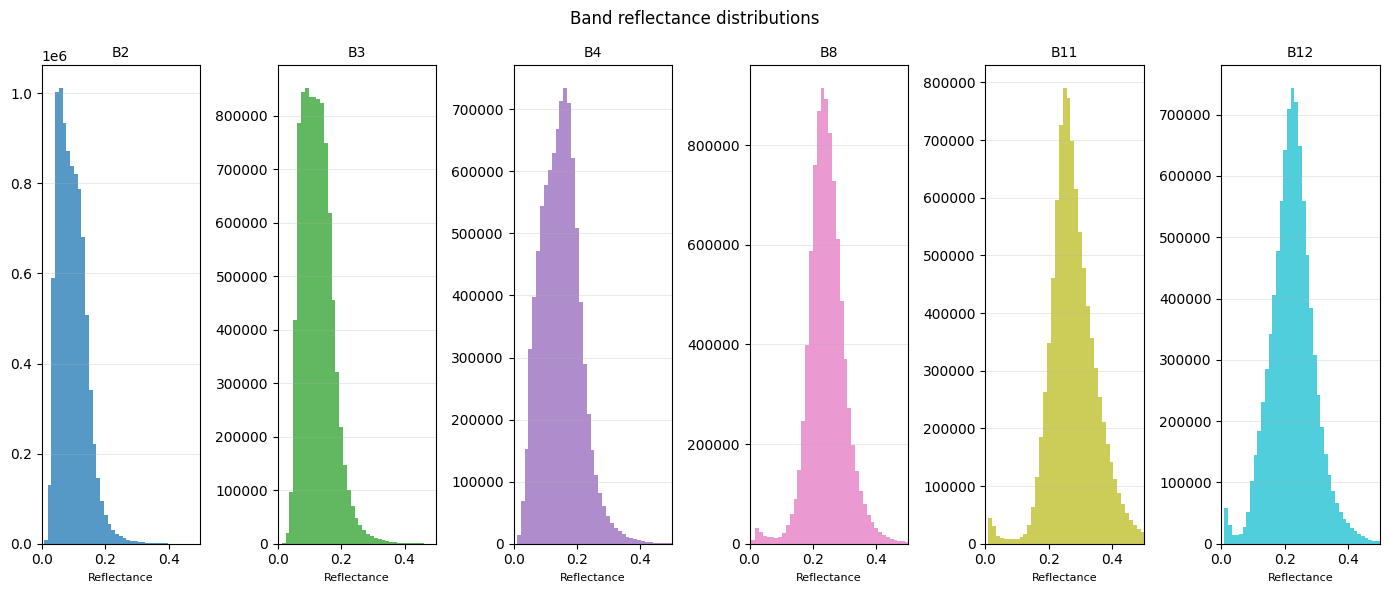

In [21]:
fig, axes = plot_band_histograms(bands, save_path=PROC_DIR / 'band_histograms.png')
plt.show()

## 6 · True colour and false colour composites

### True colour (RGB)
Bands: B4 (red), B3 (green), B2 (blue) → looks like a regular photograph.

### False colour — vegetation
Bands: B8 (NIR) → red channel, B4 → green, B3 → blue.  
**Healthy vegetation appears bright red** because chlorophyll strongly reflects
NIR. Water is black/dark blue. Urban areas appear cyan-grey.

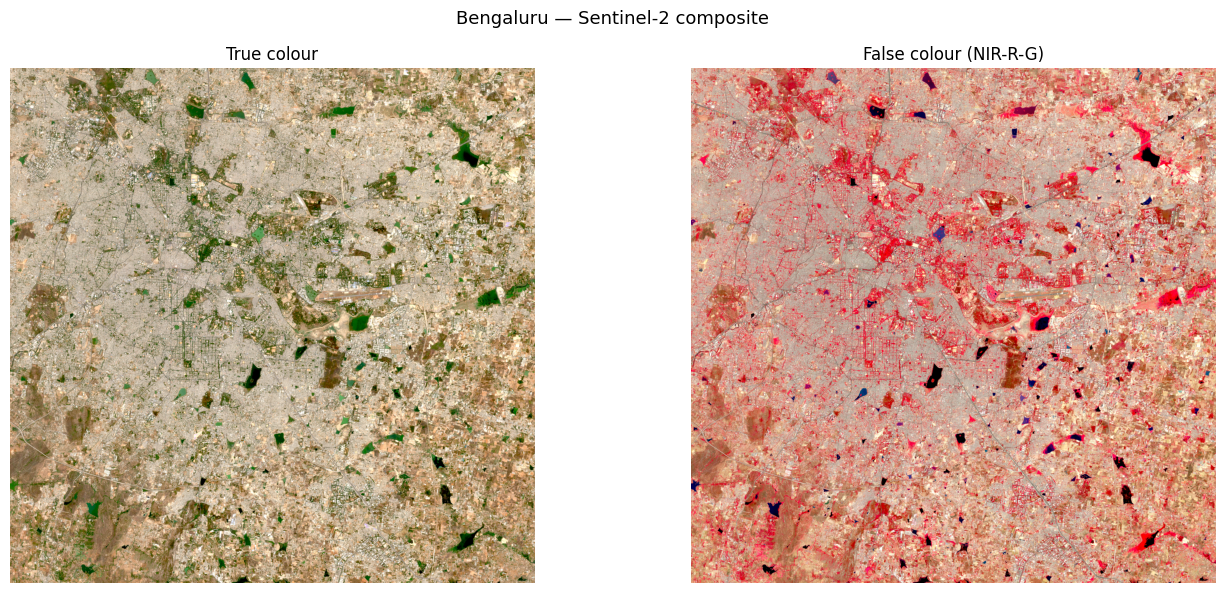

In [22]:
from band_math import true_colour, false_colour_vegetation

rgb_tc = true_colour(bands['B4'], bands['B3'], bands['B2'])
rgb_fc = false_colour_vegetation(bands['B8'], bands['B4'], bands['B3'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(rgb_tc);  ax1.set_title('True colour');          ax1.axis('off')
ax2.imshow(rgb_fc);  ax2.set_title('False colour (NIR-R-G)'); ax2.axis('off')
plt.suptitle(f'{REGION_NAME.title()} — Sentinel-2 composite', fontsize=13)
plt.tight_layout()
plt.savefig(PROC_DIR / 'composites.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Compute spectral indices

| Index | Formula | What it highlights |
|-------|---------|--------------------|
| **NDVI** | (NIR−Red)/(NIR+Red) | Vegetation density |
| **EVI** | 2.5×(NIR−Red)/(NIR+6Red−7.5Blue+1) | Vegetation (better than NDVI in dense areas) |
| **SAVI** | ((NIR−Red)/(NIR+Red+0.5))×1.5 | Vegetation over bare soil |
| **NDWI** | (Green−NIR)/(Green+NIR) | Open water bodies |
| **MNDWI** | (Green−SWIR1)/(Green+SWIR1) | Urban water (less noise) |
| **NDBI** | (SWIR1−NIR)/(SWIR1+NIR) | Built-up / urban surfaces |

In [24]:
indices = compute_all_indices(bands)
indices['EVI'] = indices['EVI'].clip(-1, 1)
print('Computed indices:')
for name, arr in indices.items():
    valid = arr[~np.isnan(arr)]
    print(f'  {name:12s}  min={valid.min():.3f}  max={valid.max():.3f}  mean={valid.mean():.3f}')

Computed indices:
  NDVI          min=-0.530  max=0.913  mean=0.256
  EVI           min=-1.000  max=1.000  mean=0.168
  SAVI          min=-0.261  max=0.776  mean=0.161
  NDWI          min=-0.822  max=0.760  mean=-0.328
  MNDWI         min=-0.793  max=0.828  mean=-0.381
  NDBI          min=-0.795  max=0.725  mean=0.059
  urban_mask    min=0.000  max=1.000  mean=0.418


In [18]:
import rasterio
with rasterio.open(LOCAL_TIF) as src:
    print("Number of bands:", src.count)
    print("Band descriptions:", src.descriptions)

Number of bands: 6
Band descriptions: ('B2', 'B3', 'B4', 'B8', 'B11', 'B12')


In [19]:
print("B8  min/max:", bands['B8'].min(), bands['B8'].max())
print("B11 min/max:", bands['B11'].min(), bands['B11'].max())
print("B3  min/max:", bands['B3'].min(), bands['B3'].max())

B8  min/max: 5.4000003e-07 0.00016872
B11 min/max: 0.00885 1.377
B3  min/max: 1.28e-06 0.00016663999


## 8 · Dashboard — all indices at a glance

Saved dashboard → ../data/processed/index_dashboard.png


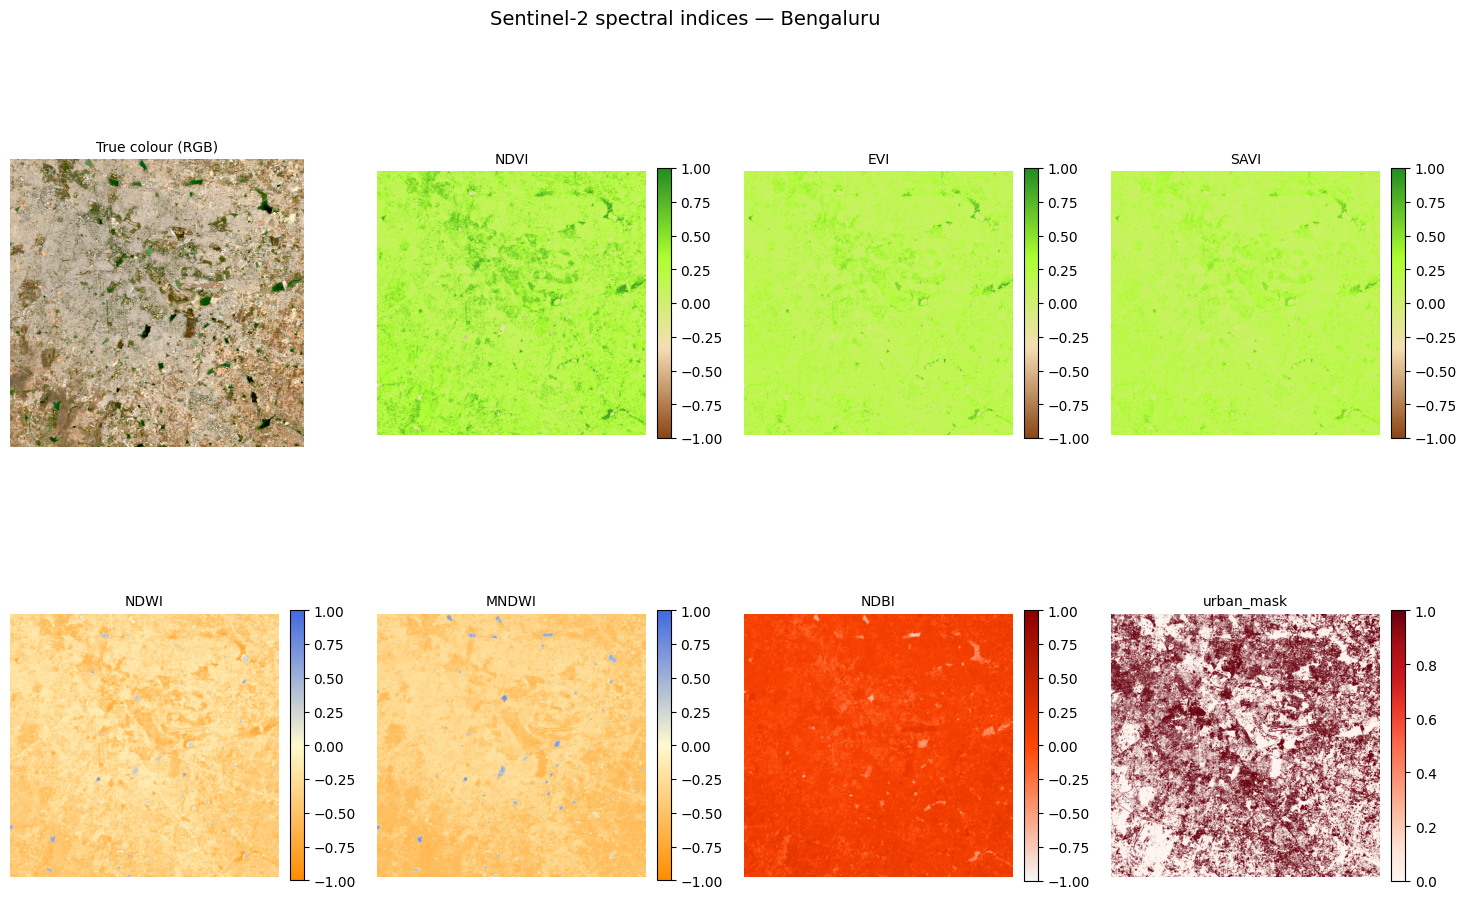

In [25]:
fig, axes = plot_index_dashboard(
    rgb         = rgb_tc,
    indices     = indices,
    region_name = REGION_NAME.title(),
    save_path   = PROC_DIR / 'index_dashboard.png',
)
plt.show()

## 9 · Export index stack as GeoTIFF

This is the output Phase 2 will consume.  
The file contains 7 bands: the 6 raw S2 bands + NDVI.  
You can extend this to include all indices as additional bands.

In [26]:
# Save raw bands + NDVI as a single multi-band GeoTIFF
output_stack = {**bands, 'NDVI': indices['NDVI']}

write_geotiff(
    arrays         = output_stack,
    output_path    = PROC_DIR / f'{FILENAME}_indexed.tif',
    reference_meta = meta,
)

# Verify
get_tile_info(PROC_DIR / f'{FILENAME}_indexed.tif')

Saved 7-band GeoTIFF → ../data/processed/bengaluru_s2_composite_2024_indexed.tif  (bands: B2, B3, B4, B8, B11, B12, NDVI)

── bengaluru_s2_composite_2024_indexed.tif ──
  Dimensions : 3064 × 3006 px
  Bands      : 7
  CRS        : EPSG:4326
  Resolution : 0.0001° / pixel
  Bounds     : W=77.4892 E=77.7645 S=12.7996 N=13.0696
  dtype      : float32
  nodata     : None


## 10 · What's next — Phase 2 preview

The indexed GeoTIFF we just created is the input to Phase 2:
- **Tile slicing**: cut the large image into 512×512 or 1024×1024 patches
- **Label generation**: use OpenStreetMap or DOTA annotations to create segmentation masks
- **Model training**: fine-tune SAM2 or SegFormer on these patches

The NDVI band we added is especially useful — it gives the model a strong
prior for separating vegetation from built-up areas without needing to
learn it from scratch.

---
*Phase 1 complete. All outputs saved to `data/processed/`.*